# 日频文本因子策略 · 完整流程 (refined)

本 notebook 在原 `gru.ipynb` 基础上完善了三点想法，并把流程拆成可复用的三个模块：

| 阶段 | 模块 | 做什么 |
|---|---|---|
| **① 文本日频化 + LLM 总结** | `text_daily_summary.py` | 新闻+研报按 (交易日, 股票) 聚合 → 300-500 字 LLM 摘要 → 全文 vs 摘要相似度验证 |
| **② 嵌入 + 有监督降维** | `embed_finbert_bertopic.py` | FinBERT 句向量 → BERTopic / 有监督 UMAP 降维（仅用训练期标签拟合）|
| **③ GRU + LGBM 因子** | `gru_lgbm_factor.py` | 日频序列建模 → GRU 特征 → LGBM → IC/RankIC/多空回测 |

> 三个阶段串联：原始文本 →①日频摘要 →②`emb_*` 特征面板 →③ 因子。
> 阶段②的输出列名就是 `emb_0..emb_{k-1}`，可直接替换原来的 `dt_lgbm.parquet`。

**贯穿全程的两条防泄漏红线：**
1. 有监督降维（②）只在**训练期**拟合，再 transform 验证/测试期；
2. 标签是未来 `label_horizon` 日收益，故 train/valid/test 之间按该长度做 **purge**（③）。


## 0. 环境与配置

In [3]:
"""环境与全局配置。

第一次跑直接执行本 cell + 「快速通道」即可（用现有 dt_lgbm.parquet 跑通 Stage 3）；
想完整体验 Stage 1+2，再往下走「真实研报 → 摘要 → 嵌入降维 → Stage 3」那一段。
"""
# pip install torch lightgbm transformers bertopic umap-learn anthropic pymysql
import importlib
import pandas as pd, numpy as np

import text_daily_summary as t1
import embed_finbert_bertopic as t2
import gru_lgbm_factor as t3
import synth_research_reports as sr            # 仅留作 fallback / 对照
import load_real_docs as L                     # 真实研报 loader (Aliyun RDS)

# 改了 .py 不想重启内核就重跑本 cell —— 强制 reload，避免拿到旧版函数
for _m in (t1, t2, t3, sr, L):
    importlib.reload(_m)

# dt_lgbm.parquet 实际为月频 (103 个唯一交易日, 430 只股票, emb 维度=4096)。
# 真实研报库 (reportdata.report_info) 覆盖 2020-01-01 ~ 2025-08-01，
# 因此 train 段下沿从 2020-01-01 起，避免「无研报」的空白期。
SEGMENTS = {
    "train": slice("2020-01-01", "2022-12-31"),
    "valid": slice("2023-01-01", "2024-03-31"),
    "test":  slice("2024-04-01", "2025-08-01"),
}


## 🚀 快速通道：用现有 `dt_lgbm.parquet` 直接跑 Stage 3

如果暂时没有原始研报/新闻文本，可以**跳过 Stage 1+2**，用磁盘上已有的特征面板
（`dt_lgbm.parquet`，emb_4096 月频）端到端拿到因子和 IC。这是**最快验证 Stage 3 跑通**的路径。


In [5]:
panel = pd.read_parquet("dt_lgbm.parquet")
print(panel.shape, "| dates:", panel.date.nunique(), "| stocks:", panel.stkcd.nunique())

cfg_fast = t3.FactorConfig(
    seq_len=6,                # 月频：6 步 ≈ 半年历史
    label_horizon=1,          # 月频：1 步 purge（label 是 20 交易日前瞻收益 ≈ 1 月）
    max_gap_days=None,        # 非日频时关掉日历缺口过滤
    label_col="vwap_rk", return_col="vwap_ret20", feature_prefix="emb_",
    proj_dim=128, gru_hidden=64, gru_layers=2,
    epochs=10, batch_size=128, patience=3,
    lgbm_num_boost_round=500, lgbm_early_stopping=30,
    device="auto",
)
res_fast = t3.run_pipeline(panel, SEGMENTS, cfg_fast)
print(pd.DataFrame(res_fast["metrics"]).T[["IC_mean", "RankIC_mean", "ICIR", "n_days"]])
if res_fast["backtest"] is not None:
    print(f"test L/S mean={res_fast['backtest']['ls_mean']:.4f}  ann.Sharpe={res_fast['backtest']['ls_sharpe']:.2f}")


(11151, 4100) | dates: 103 | stocks: 430
[warn] 1 duplicate (date, stkcd) rows in input -- keeping first occurrence
#features=4096  device=cpu
sequences: X=(9237, 6, 4096)  y=(9237,)
  train: 3016 samples
  valid: 1779 samples
  test: 2301 samples
Epoch 01 | train=1.252600 | valid=1.099952
Epoch 02 | train=1.180406 | valid=1.105179
Epoch 03 | train=1.126997 | valid=1.157993
Epoch 04 | train=1.065926 | valid=1.150024
Early stopping.
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[2]	train's l2: 1.18283	valid's l2: 1.08945
[train] IC=0.3222 RankIC=0.3040 ICIR=2.847 (n_days=35)
[valid] IC=-0.0074 RankIC=-0.0127 ICIR=-0.066 (n_days=14)
[test] IC=-0.0228 RankIC=-0.0012 ICIR=-0.211 (n_days=17)
[test] L/S mean=-0.0094 ann.Sharpe=-3.83
        IC_mean  RankIC_mean      ICIR  n_days
train  0.322164     0.304004  2.846881    35.0
valid -0.007370    -0.012653 -0.065762    14.0
test  -0.022775    -0.001150 -0.211295    17.0
test L/S mean=-0.0094  an

In [3]:
# 1.0 准备 raw_docs。三种来源：
#   "real" = 从阿里云 reportdata.report_info 拉真实研报（推荐；本路径已实现）
#   "synth"= 用 LLM/离线合成器造文本（管线 smoke test 用）
#   "file" = 之前导出的 parquet
DATA_SOURCE = "real"

if DATA_SOURCE == "real":
    # 真实研报：reportdata.report_info 里 stocks 是「中文名」逗号分隔，
    # load_real_docs 内部用 financedata.asharedescription + asharepreviousname
    # 把名字解析成 stkcd (6 位 + .SH/.SZ/.BJ)。
    load_cfg = L.LoadConfig(
        start="2020-01-01", end="2025-08-01",  # 与 SEGMENTS 一致
        batch_months=3,                         # DB 分块拉取，控内存
        use_content_fallback=True,
        max_text_chars=4000, min_text_chars=30,
    )
    raw_docs = L.load_real_docs(load_cfg)

    # 把研报日期 snap 到 dt_lgbm.parquet 的（月频）面板日期上，便于下游 join 标签。
    # 报告 D 日落在面板下一个日期 P 上 (P >= D, P-D <= max_forward_days)；
    # 没有可对齐面板日期的报告被丢弃。
    panel_keys = pd.read_parquet("dt_lgbm.parquet")[["date", "stkcd"]]
    raw_docs = L.snap_to_panel_dates(raw_docs, panel_keys, max_forward_days=40)

elif DATA_SOURCE == "synth":
    all_keys = pd.read_parquet("dt_lgbm.parquet")[["date", "stkcd"]].drop_duplicates()
    stk_pool = all_keys["stkcd"].drop_duplicates().sample(8, random_state=42).tolist()
    keys = all_keys[all_keys["stkcd"].isin(stk_pool)].reset_index(drop=True)
    print(f"synth grid: {len(keys)} rows = {keys.stkcd.nunique()} stocks × ~{keys.date.nunique()} dates")
    gen = sr.make_offline_generator()
    raw_docs = sr.generate_panel(keys, gen,
                                 cfg=sr.SynthConfig(docs_per_day=2, sources=("research", "news")))

else:  # "file"
    raw_docs = pd.read_parquet("raw_docs.parquet")

print(raw_docs.shape, "| cols:", list(raw_docs.columns))
raw_docs.head()


[load_real_docs] building name->stkcd map ...


c:\Code\gjzq\grumodel\load_real_docs.py:79: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cur_df = pd.read_sql(
c:\Code\gjzq\grumodel\load_real_docs.py:87: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  prev_df = pd.read_sql(


  mapped 13,491 unique names, 88 ambiguous
[load_real_docs] pulling 2020-01-01 ~ 2020-03-31 ...


c:\Code\gjzq\grumodel\load_real_docs.py:194: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn, params=(a_s, b_s))


  rows: 49,101 -> 42,910 after name resolution  (87.4% mapped)
[load_real_docs] pulling 2020-04-01 ~ 2020-06-30 ...


...

c:\Code\gjzq\grumodel\load_real_docs.py:194: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn, params=(a_s, b_s))


  rows: 34,689 -> 30,506 after name resolution  (87.9% mapped)
[load_real_docs] pulling 2025-07-01 ~ 2025-08-01 ...


c:\Code\gjzq\grumodel\load_real_docs.py:194: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn, params=(a_s, b_s))


  rows: 5,723 -> 5,012 after name resolution  (87.6% mapped)
[load_real_docs] DONE  rows=908,786  dates=2026  stocks=5586
(57121, 5) | cols: ['date', 'stkcd', 'text', 'source', 'title']


,date,stkcd,text,source,title
0,2020-01-02,000513.SZ,2020年医药行业或科技属性偏强，消费属性偏弱经济弱复苏，资金面偏宽松。股市进入全面牛，医药...,research,医药生物行业2020年投资策略：或科技属性偏强、消费属性偏弱
1,2020-01-02,000513.SZ,2019年收官，2019年的医药板块行情波澜壮阔。全年板块涨幅36.85%，位于28个一级子...,research,医药生物月报：2020年 医药行业新的长牛周期开启
2,2020-01-02,002007.SZ,2019年收官，2019年的医药板块行情波澜壮阔。全年板块涨幅36.85%，位于28个一级子...,research,医药生物月报：2020年 医药行业新的长牛周期开启
3,2020-01-02,002044.SZ,2020年医药行业或科技属性偏强，消费属性偏弱经济弱复苏，资金面偏宽松。股市进入全面牛，医药...,research,医药生物行业2020年投资策略：或科技属性偏强、消费属性偏弱
4,2020-01-02,002044.SZ,2019年收官，2019年的医药板块行情波澜壮阔。全年板块涨幅36.85%，位于28个一级子...,research,医药生物月报：2020年 医药行业新的长牛周期开启


In [4]:
# 1.1 raw_docs → 每日单条全文（同 (date, stkcd) 的多篇合并、超长截断）
agg_cfg = t1.AggregateConfig(max_chars=4000)
daily = t1.aggregate_daily(raw_docs, agg_cfg)

# 1.2 LLM 摘要（300-500 字，落盘缓存避免重跑）
#     ⚠️ 无 API key 时，用一个简单兜底摘要器跑通；要真 LLM 替换 summarize_fn。
def _offline_summarize(text: str) -> str:
    t = " ".join(text.split())
    return t[:480] if len(t) > 480 else t

summarize_fn = _offline_summarize
# summarize_fn = t1.make_anthropic_summarizer(model="claude-sonnet-4-5")  # ← 切真实 LLM

sum_cfg = t1.SummaryConfig(target_min=300, target_max=500, cache_dir="./cache_summaries")
daily = t1.summarize_panel(daily, summarize_fn, cfg=sum_cfg, text_col="full_text")
print(daily.shape, "| cols:", list(daily.columns))
daily.head(2)


NameError: name 'raw_docs' is not defined

### 1.3 全文 vs 摘要 相似度对比

用**同一个**嵌入器编码全文与摘要，比较余弦相似度，验证摘要是否保留了信号。
低于阈值的样本被 flag 出来，用于人工抽检或回退到全文。


In [8]:
%pip install transformers umap-learn bertopic

  Using cached transformers-5.9.0-py3-none-any.whl.metadata (33 kB)
  Using cached umap_learn-0.5.12-py3-none-any.whl.metadata (24 kB)
  Using cached bertopic-0.17.4-py3-none-any.whl.metadata (24 kB)
  Using cached huggingface_hub-1.16.1-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached hf_xet-1.5.0-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached transformers-5.9.0-py3-none-any.whl (10.8 MB)
Using cached huggingface_hub-1.16.1-py3-none-any.whl (668 kB)
Using cached hf_xet-1.5.0-cp37-abi3-win_amd64.whl (4.0 MB)
U


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# 注：valuesimplex/FinBERT 已不可公开下载；用公开中文 BERT 替代。
# 想用真 FinBERT 请自己 hf auth login 后再换回。
embedder = t2.FinBertEmbedder(t2.EmbedConfig(model_name="bert-base-chinese"))
qc = t1.summary_similarity(daily, embedder.encode, low_threshold=0.80)
print(f"中位余弦相似度 = {qc['cos_median']:.3f} | 压缩率 = {qc['compression_mean']:.2%} | "
      f"低于阈值占比 = {qc['pct_below_threshold']:.2%}")
qc["flagged"].head()   # 摘要可能丢信号的样本

# 进阶：相似度只是表层验证。真正的"信息保留"应看下游因子 IC：

#   把 daily['full_text'] 与 daily['summary'] 各跑一遍 ②③，对比 test IC。#   见文末"全文 vs 摘要 信息保留对比"。

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


中位余弦相似度 = 0.986 | 压缩率 = 18.03% | 低于阈值占比 = 0.00%


,,full_text,n_docs,n_chars,summary,summary_chars,cos_full_summary,compression
date,stkcd,,,,,,,


## ② FinBERT 嵌入 + 有监督降维

⚠️ **只用训练期标签拟合降维器**，否则未来标签会泄漏进特征。


In [1]:
TEXT_COL = "summary"          # 想对比全文就改成 "full_text"

embedder = t2.FinBertEmbedder(t2.EmbedConfig(model_name="bert-base-chinese"))

# 2.1 句向量（全样本）
emb_all = t2.embed_panel(daily, embedder, text_col=TEXT_COL)   # (N, 768)

# 2.2 切分训练/验证/测试（按日期）
seg_masks = t2.split_by_segments(daily, SEGMENTS)

# 2.3 标签 / 收益：从已有 panel（dt_lgbm.parquet）按 (date,stkcd) 对齐
_p = panel.drop_duplicates(["date", "stkcd"]).set_index(["date", "stkcd"])
label = _p["vwap_rk"]
ret20 = _p["vwap_ret20"]
y_all = label.reindex(daily.index).to_numpy()
print("emb:", emb_all.shape, "| labeled rows:", (~pd.isna(y_all)).sum())


NameError: name 't2' is not defined

In [11]:
# 2.3 有监督 UMAP（+可选 BERTopic）只 fit 训练期，再 transform 全样本
red_cfg = t2.ReduceConfig(n_components=10, n_bins=10, use_bertopic=True, random_state=42)
reducer = t2.SupervisedReducer(red_cfg)
reducer.fit(
    embeddings_train=emb_all[seg_masks["train"]],
    y_train=y_all[seg_masks["train"]],
    docs_train=daily[TEXT_COL][seg_masks["train"]].tolist(),
)
reduced = reducer.transform_embeddings(emb_all)               # (N, 10)  -> emb_0..emb_9
print("reduced:", reduced.shape)

c:\Users\zexua\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


reduced: (7873, 10)


In [12]:
# 2.5 组装阶段③要的面板：[date, stkcd] × emb_* (+ 标签 + 原始收益)
panel_new = t2.build_feature_panel(
    daily, reduced,
    label_series=label.reindex(daily.index).rename("vwap_rk"),
    return_series=ret20.reindex(daily.index).rename("vwap_ret20"),
)
panel_new.to_parquet("dt_lgbm_text.parquet")
print(panel_new.shape, "| cols:", list(panel_new.columns)[:6], "...")
panel_new.head()


(7873, 12) | cols: ['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5'] ...


emb_0     emb_1     emb_2     emb_3     emb_4  \
date       stkcd                                                         
2020-01-02 000513.SZ  9.130476  5.562413  5.658997  3.526130  4.788672   
           002007.SZ  8.005128  6.553430  3.616484  1.956741 -2.050873   
           002044.SZ  9.130476  5.562413  5.658997  3.526130  4.788672   
           002675.SZ  9.130476  5.562413  5.658997  3.526130  4.788672   
           002773.SZ  9.130476  5.562413  5.658997  3.526130  4.788672   

                         emb_5      emb_6     emb_7     emb_8     emb_9  \
date       stkcd                                                          
2020-01-02 000513.SZ  4.235020   4.102071  5.225359  8.864142  3.103249   
           002007.SZ -2.556633  17.049076  5.436523  7.491332  6.472644   
           002044.SZ  4.235020   4.102071  5.225359  8.864142  3.103249   
           002675.SZ  4.235020   4.102071  5.225359  8.864142  3.103249   
           002773.SZ  4.235020   4.102071  5.225359  8.864142  3.103249   

                       vwap_rk  vwap_ret20  
date       stkcd                            
2020-01-02 000513.SZ  1.382985    0.179561  
           002007.SZ  1.398674    0.187248  
           002044.SZ  0.181352   -0.076818  
           002675.SZ  0.353014   -0.061257  
           002773.SZ  0.520984   -0.041147

## ③ GRU + LGBM 因子（日频、防泄漏、因子原生评估）

相比原始 `gru.ipynb` 的改动：
- 序列窗口改为**交易日**，并对停牌造成的日历缺口做 `max_gap_days` 过滤；
- train/valid/test 之间按 `label_horizon` 做 **purge**，去掉标签重叠；
- 评估从 MSE 换成截面 **IC / RankIC / ICIR + 多空回测**；
- 可选 `oof_gru_features=True` 处理 GRU→LGBM 的堆叠泄漏。


In [13]:
# 用 ② 输出的 panel_new（emb_0..emb_9，月频对齐）跑因子
cfg = t3.FactorConfig(
    seq_len=6, label_horizon=1, max_gap_days=None,   # 月频参数
    label_col="vwap_rk", return_col="vwap_ret20", feature_prefix="emb_",
    gru_hidden=64, gru_layers=2, epochs=10, oof_gru_features=False,
)
res = t3.run_pipeline(panel_new, SEGMENTS, cfg)


#features=10  device=cpu
sequences: X=(6242, 6, 10)  y=(6242,)
  train: 2233 samples
  valid: 1681 samples
  test: 2129 samples
Epoch 01 | train=1.252528 | valid=1.104527
Epoch 02 | train=1.220230 | valid=1.098593
Epoch 03 | train=1.190968 | valid=1.094094
Epoch 04 | train=1.169200 | valid=1.103466
Epoch 05 | train=1.141159 | valid=1.101046
Epoch 06 | train=1.109204 | valid=1.115574
Epoch 07 | train=1.088457 | valid=1.175174
Early stopping.
Training until validation scores don't improve for 50 rounds
[50]	train's l2: 0.745491	valid's l2: 1.12735
Early stopping, best iteration is:
[2]	train's l2: 1.19668	valid's l2: 1.08911
[train] IC=0.3596 RankIC=0.3335 ICIR=2.417 (n_days=30)
[valid] IC=0.0105 RankIC=0.0004 ICIR=0.099 (n_days=14)
[test] IC=-0.0074 RankIC=-0.0030 ICIR=-0.090 (n_days=17)
[test] L/S mean=0.0045 ann.Sharpe=2.52


        IC_mean  RankIC_mean      ICIR  n_days
train  0.359622     0.333460  2.417174    30.0
valid  0.010519     0.000442  0.098534    14.0
test  -0.007388    -0.003026 -0.089750    17.0
test rows=2129  pred.std=0.03494  y.std=1.022
per-date pred.std (top 5):
date
2024-04-01    0.040249
2024-05-06    0.038934
2024-06-03    0.034950
2024-07-01    0.034689
2024-08-01    0.032624
Name: pred, dtype: float64


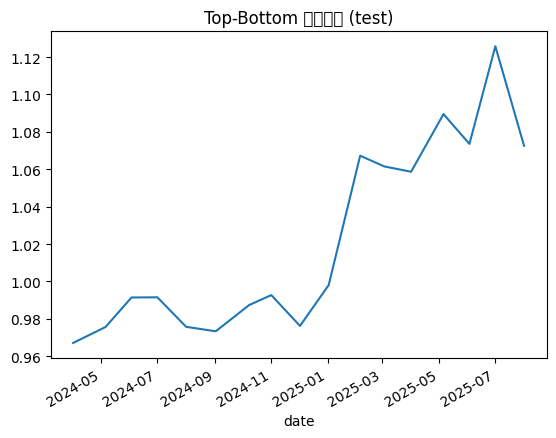

In [14]:
# 结果
import pandas as pd
print(pd.DataFrame(res["metrics"]).T[["IC_mean","RankIC_mean","ICIR","n_days"]])

# —— 诊断：n_days=0 / IC=NaN 时定位是哪个环节出问题 ——
p = res["preds"]["test"]
y = res["df_gru"].loc[p.index, "vwap_rk"]
print(f"test rows={len(p)}  pred.std={p.std():.4g}  y.std={y.std():.4g}")
print("per-date pred.std (top 5):")
print(p.groupby(p.index.get_level_values(0)).std().head())

if res["backtest"] is not None and len(res["backtest"]["ls_cum"]) > 0:
    res["backtest"]["ls_cum"].plot(title="Top-Bottom 多空净值 (test)")

# 落地因子
test_factor = res["preds"]["test"].rename("gru_lgbm_factor").reset_index()
test_factor.to_csv("artifacts_gru/gru_lgbm_test_factor_long.csv", index=False)


In [15]:
# ====== 诊断：为什么 Stage 3 输出是空的 ======
import numpy as np, pandas as pd

# panel_new 是 MultiIndex (date, stkcd)；统一拿出来用
pn = panel_new.reset_index() if isinstance(panel_new.index, pd.MultiIndex) else panel_new.copy()

print("--- panel_new ---")
print("shape:", panel_new.shape, " cols:", list(panel_new.columns)[:8], "...")
print("date range:", pn["date"].min(), "->", pn["date"].max())
print("unique stkcd:", pn["stkcd"].nunique(), " unique date:", pn["date"].nunique())
print("rows per date describe:")
print(pn.groupby("date").size().describe())
print("rows per stkcd describe:")
print(pn.groupby("stkcd").size().describe())

# 按 SEGMENTS 切片，看每段还剩多少行 / 多少天 / 多少股
for name, sl in SEGMENTS.items():
    s, e = sl.start, sl.stop
    sub = pn[(pn["date"] >= pd.Timestamp(s)) & (pn["date"] <= pd.Timestamp(e))]
    print(f"  [{name}] {s}->{e}  rows={len(sub)}  dates={sub['date'].nunique()}  stks={sub['stkcd'].nunique()}")

# label 缺失
print("vwap_rk NaN ratio:", pn["vwap_rk"].isna().mean())
print("emb_* NaN ratio   :", pn.filter(like="emb_").isna().mean().mean())

print("\n--- res internals ---")
for split in ["train","valid","test"]:
    pp = res["preds"].get(split)
    if pp is None or len(pp) == 0:
        print(f"  preds[{split}]: EMPTY"); continue
    yy = res["df_gru"].loc[pp.index, cfg.label_col]
    sizes = pp.groupby(pp.index.get_level_values(0)).size()
    stds  = pp.groupby(pp.index.get_level_values(0)).std()
    print(f"  preds[{split}]: rows={len(pp)} dates={pp.index.get_level_values(0).nunique()} "
          f"pred.std={pp.std():.4g} y.std={yy.std():.4g}  "
          f"per-day n median={sizes.median():.0f}  per-day pred.std>0 ratio={(stds>1e-12).mean():.2f}")


--- panel_new ---
shape: (7873, 12)  cols: ['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7'] ...
date range: 2020-01-02 00:00:00 -> 2025-08-01 00:00:00
unique stkcd: 372  unique date: 68
rows per date describe:
count     68.000000
mean     115.779412
std       51.040764
min       24.000000
25%       75.750000
50%       99.000000
75%      159.000000
max      222.000000
dtype: float64
rows per stkcd describe:
count    372.000000
mean      21.163978
std       15.792028
min        1.000000
25%        6.000000
50%       19.000000
75%       34.000000
max       58.000000
dtype: float64
  [train] 2020-01-01->2022-12-31  rows=3613  dates=36  stks=303
  [valid] 2023-01-01->2024-03-31  rows=2008  dates=15  stks=296
  [test] 2024-04-01->2025-08-01  rows=2252  dates=17  stks=304
vwap_rk NaN ratio: 0.0
emb_* NaN ratio   : 0.0

--- res internals ---
  preds[train]: rows=2233 dates=30 pred.std=0.03575 y.std=1.108  per-day n median=65  per-day pred.std>0 ratio=1.00
  preds[valid]

## 全文 vs 摘要 · 信息保留对比（闭环验证）

把 `TEXT_COL` 分别设为 `"full_text"` 与 `"summary"`，各自跑完 ②③，对比 test 期 IC。
若摘要版 IC ≈ 全文版（甚至更高，因为去噪），说明 300-500 字摘要在大幅降低
嵌入/存储/LLM 成本的同时**没有损失 alpha**——这是用摘要替代全文的核心依据。


In [16]:
def factor_ic_for(text_col):
    emb = t2.embed_panel(daily, embedder, text_col=text_col)
    r = t2.SupervisedReducer(red_cfg)
    r.fit(emb[seg_masks["train"]], y_all[seg_masks["train"]],
          daily[text_col][seg_masks["train"]].tolist())
    p = t2.build_feature_panel(
        daily, r.transform_embeddings(emb),
        label.reindex(daily.index).rename("vwap_rk"),
        ret20.reindex(daily.index).rename("vwap_ret20"),
    )
    return t3.run_pipeline(p, SEGMENTS, cfg)["metrics"]["test"]

cmp = pd.DataFrame({"full_text": factor_ic_for("full_text"),
                    "summary":   factor_ic_for("summary")}).T
cmp[["IC_mean", "RankIC_mean", "ICIR"]]


KeyboardInterrupt: 